In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib
import json
import os

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, LeakyReLU, BatchNormalization, SpatialDropout1D,Bidirectional, LSTM, Dropout, Dense, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import regularizers

In [2]:
PROJECT_ROOT = os.path.dirname(os.getcwd()) 

DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODEL_SAVE_PATH = os.path.join(PROJECT_ROOT, 'models')
OUTPUT_PATH = os.path.join(PROJECT_ROOT, 'results')

paths = [DATA_PATH, MODEL_SAVE_PATH, OUTPUT_PATH]

print(f"Project root: {PROJECT_ROOT}")
for p in paths:
    os.makedirs(p, exist_ok=True)
    print(f"  {'Exists:' if os.path.exists(p) else "Doesn't Exist"} {p}")

Project root: d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison
  Exists: d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\data\processed
  Exists: d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\models
  Exists: d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\results


In [3]:
data = np.load(os.path.join(DATA_PATH, 'cnn_lstm_ready.npz'))

X_train, y_train = data['X_train'], data['y_train']
X_test,  y_test  = data['X_test'],  data['y_test']

y_scaler = joblib.load(os.path.join(MODEL_SAVE_PATH, 'minmax_y_scaler.pkl'))

In [4]:
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1351, 22, 26) | Test: (322, 22, 26)


In [13]:
model = Sequential()

model.add(GaussianNoise(0.015, input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Conv1D(filters = 32, kernel_size = 3, padding = 'same', kernel_regularizer = regularizers.l2(1e-3)))
model.add(LeakyReLU(alpha = 0.1))
model.add(BatchNormalization())
model.add(SpatialDropout1D(0.3))

model.add(Conv1D(filters = 16, kernel_size = 3, padding = 'same', dilation_rate = 2,kernel_regularizer = regularizers.l2(1e-3)))
model.add(LeakyReLU(alpha = 0.1))
model.add(BatchNormalization())
model.add(SpatialDropout1D(0.3))

model.add(Bidirectional(LSTM(units = 16, activation = 'tanh', return_sequences = False,recurrent_dropout = 0.25, kernel_regularizer = regularizers.l2(1e-3))))
model.add(Dropout(0.4))

model.add(Dense(8, kernel_regularizer = regularizers.l2(1e-3)))
model.add(LeakyReLU(alpha = 0.1))
model.add(Dropout(0.2))
model.add(Dense(1))

d:\conda_envs\ai_two\Lib\site-packages\keras\src\layers\regularization\gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\conda_envs\ai_two\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [14]:
model.compile(
    optimizer = AdamW(learning_rate = 5e-4, weight_decay = 2.5e-4, clipnorm = 1.0),
    loss=tf.keras.losses.Huber(delta = 1.0),
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_1                │ (None, 22, 26)         │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 22, 32)         │         2,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 22, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 22, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 22, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 22, 16)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,769 (34.25 KB)

 Trainable params: 8,673 (33.88 KB)

 Non-trainable params: 96 (384.00 B)

In [15]:
callbacks = [
    EarlyStopping(
        monitor = "val_loss",
        patience = 20,
        mode = "min",
        restore_best_weights = True,
        verbose = 1
    ),
    ReduceLROnPlateau(
        monitor = "val_loss",
        factor = 0.5,
        patience = 6,
        min_lr = 1e-7,
        mode = "min",
        verbose = 1
    )
]

In [16]:
history = model.fit(
    X_train, y_train,
    epochs = 300,
    batch_size = 32,
    validation_data = (X_test, y_test),
    callbacks = callbacks,
    verbose = 1
)

Epoch 1/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.2437 - mae: 0.4116 - val_loss: 0.1773 - val_mae: 0.3321 - learning_rate: 5.0000e-04
Epoch 2/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1985 - mae: 0.3310 - val_loss: 0.1562 - val_mae: 0.2686 - learning_rate: 5.0000e-04
Epoch 3/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1806 - mae: 0.2993 - val_loss: 0.1421 - val_mae: 0.2225 - learning_rate: 5.0000e-04
Epoch 4/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1680 - mae: 0.2764 - val_loss: 0.1308 - val_mae: 0.1867 - learning_rate: 5.0000e-04
Epoch 5/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1563 - mae: 0.2526 - val_loss: 0.1201 - val_mae: 0.1436 - learning_rate: 5.0000e-04
Epoch 6/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1498 - mae: 0.2445 - val_loss: 0.1190 - val_mae: 0.1439 - learning_rate: 5.0000e-04
Epoch 7/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1440 - mae: 0.2311 - val_loss: 0.1144 - val_mae: 0.1338 - lear

In [17]:
def evaluate(model, name):
    preds_scaled = model.predict(X_test)
    preds = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1))
    actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))

    mae = mean_absolute_error(actual, preds)
    mse = mean_squared_error(actual, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, preds)

    print("\n" + "="*50)
    print(f"  EVALUATION: {name.upper()}")
    print("="*50)
    print(f"  R² Score  : {r2:.4f}")
    print(f"  RMSE      : ${rmse:.2f}")
    print(f"  MAE       : ${mae:.2f}")
    print(f"  MSE       : ${mse:.2f}")
    print("="*50)
    
    return {
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mse': mse,
        'actual': actual.flatten(),
        'pred': preds.flatten()
    }

results = {'CNN-LSTM': evaluate(model, "Cnn-LSTM")}

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

  EVALUATION: CNN-LSTM
  R² Score  : 0.8865
  RMSE      : $1.57
  MAE       : $1.27
  MSE       : $2.45


In [18]:
def unscale(y):
    return y_scaler.inverse_transform(y.reshape(-1, 1)).flatten()

model_dict = {
    'Cnn-LSTM': model,
}

results = {}
for name, md in model_dict.items():
    pred_s = md.predict(X_test).flatten()
    pred = unscale(pred_s)
    actual = unscale(y_test)

    results[name] = {
        'pred': pred,
        'actual': actual,
        'mse': mean_squared_error(actual, pred),
        'rmse': np.sqrt(mean_squared_error(actual, pred)),
        'mae': mean_absolute_error(actual, pred),
        'r2': r2_score(actual, pred),
    }

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


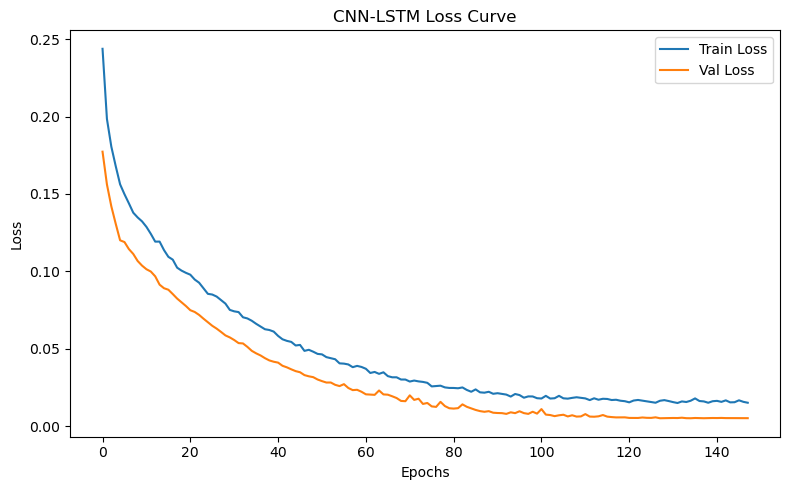

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')

plt.title('CNN-LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

output_file = os.path.join(OUTPUT_PATH, 'cnn_lstm_loss_curves.png')
plt.savefig(output_file, dpi = 150, bbox_inches = 'tight')

plt.show()

In [20]:
name, res = next(iter(results.items()))

print("\n" + "="*50)
print(f"  FINAL RESULTS SUMMARY: {name.upper()}")
print("="*50)
print(f"  R² Score  : {res['r2']:.4f}")
print(f"  RMSE      : ${res['rmse']:.2f}")
print(f"  MAE       : ${res['mae']:.2f}")
print(f"  MSE       : ${res['mse']:.2f}")
print("="*50)


  FINAL RESULTS SUMMARY: CNN-LSTM
  R² Score  : 0.8865
  RMSE      : $1.57
  MAE       : $1.27
  MSE       : $2.45


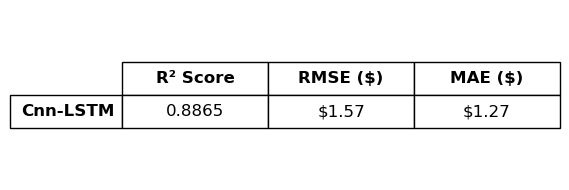

In [24]:
metrics_df = pd.DataFrame({
    name: {
        'R² Score': f"{res['r2']:.4f}",
        'RMSE ($)': f"${res['rmse']:.2f}",
        'MAE ($)': f"${res['mae']:.2f}",
    }
    for name, res in results.items()
}).T


fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')


table = ax.table(
    cellText = metrics_df.values,
    rowLabels = metrics_df.index,
    colLabels = metrics_df.columns,
    cellLoc = 'center',
    loc = 'center'
)


table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)


for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.get_text().set_weight('bold')


plt.tight_layout()
output_file = os.path.join(OUTPUT_PATH, 'cnn_lstm_metrics_comparison.png')
plt.savefig(output_file, dpi = 150, bbox_inches = 'tight')
plt.show()

In [21]:
model_file_path = os.path.join(MODEL_SAVE_PATH, 'model_cnn_lstm.h5')
model.save(model_file_path)

print(f"\n" + "="*50)
print(f"Model saved successfully")
print(f"Path: {model_file_path}")
print("="*50)


Model saved successfully
Path: d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\models\model_cnn_lstm.h5


### Training History

In [22]:
history_dict = history.history

clean_history = {metric: [float(value) for value in values] for metric, values in history_dict.items()}

save_path = os.path.join(OUTPUT_PATH, 'history_cnn-lstm.json')
with open(save_path, 'w') as f:json.dump(clean_history, f, indent=2)

print(f"\n" + "="*50)
print(f"Training metrics exported successfully")
print(f"Path: {save_path}")
print("="*50)


Training metrics exported successfully
Path: d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\results\history_cnn-lstm.json


### Saving results in CSV

In [23]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'R2': [r['r2'] for r in results.values()],
    'RMSE': [r['rmse'] for r in results.values()],
    'MAE': [r['mae'] for r in results.values()],
    'MSE': [r['mse'] for r in results.values()],
})

output_file = os.path.join(OUTPUT_PATH, 'cnn_lstm_model_result.csv')
results_df.to_csv(output_file, index=False)

print("\n" + "="*50)
print(f"SUCCESS: Metrics exported to CSV!")
print(f"Path: {output_file}")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)


SUCCESS: Metrics exported to CSV!
Path: d:\AI_TWO\NLP\Deep-Sequence-Model-Comparison\results\cnn_lstm_model_result.csv
   Model       R2     RMSE      MAE      MSE
Cnn-LSTM 0.886481 1.566717 1.269878 2.454603
